In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from preclean import preprocessing
import optuna
from sklearn.model_selection import train_test_split
from optuna.integration import XGBoostPruningCallback

/Users/leadervieux/Documents/StageB/project/.finance/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


In [2]:
# ── Uploading train ─────────────────────────────────
df_transac = pd.read_csv('data/train_transaction.csv')
df_id      = pd.read_csv('data/train_identity.csv')
df_train   = preprocessing(df_transac, df_id)

X = df_train.drop(columns=['TransactionID', 'isFraud'])
y = df_train['isFraud']

# ── Uploading test Kaggle ───────────────────────────
df_test_t  = pd.read_csv('data/test_transaction.csv')
df_test_i  = pd.read_csv('data/test_identity.csv')
df_test    = preprocessing(df_test_t, df_test_i)

X_test = df_test.drop(columns=['TransactionID'])

# Aligning columns (because of the get_dummies)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

 Final shape: (590540, 825)
  Residuals NaN (float) : 275762358
 Final shape: (506691, 463)
  Residuals NaN (float) : 90604215


Choice of parameters with Optuna

In [3]:
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=0.2, stratify=y, random_state=42
)
print(f"Échantillon : {len(X_sample)} lignes au lieu de {len(X)}")

Échantillon : 118108 lignes au lieu de 590540


In [4]:
def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 9), #under 3 -> under fitting, above 9 -> over fitting
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True), #standard to be sure of the convergence
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0), #the number of data per tree
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20), #constraint on each tree
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # Fixed parameters
        'n_estimators':          300,
        'scale_pos_weight':      len(y[y==0]) / len(y[y==1]),
        'tree_method':           'hist',
        'eval_metric':           'auc',
        'early_stopping_rounds': 30,
        'random_state':          42,
        'n_jobs':                -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for idx_train, idx_val in skf.split(X_sample, y_sample):
        X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
        y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

        pruning_callback = XGBoostPruningCallback(trial, 'validation_0-auc')

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)



study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

[I 2026-06-23 12:51:11,218] A new study created in memory with name: no-name-76f8117b-27a5-4e6b-b85e-da52e98aec7a
Best trial: 0. Best value: 0.90054:  10%|█         | 1/10 [03:03<27:32, 183.66s/it]

[I 2026-06-23 12:54:14,890] Trial 0 finished with value: 0.900539667671933 and parameters: {'max_depth': 4, 'learning_rate': 0.010177912996200545, 'subsample': 0.537814631698387, 'colsample_bytree': 0.8384509031648555, 'min_child_weight': 10, 'reg_alpha': 0.4329354120710425, 'reg_lambda': 5.853410358506369}. Best is trial 0 with value: 0.900539667671933.


Best trial: 1. Best value: 0.945118:  20%|██        | 2/10 [06:29<26:11, 196.47s/it]

[I 2026-06-23 12:57:40,325] Trial 1 finished with value: 0.9451183722145764 and parameters: {'max_depth': 9, 'learning_rate': 0.04362046207751783, 'subsample': 0.8588560249678197, 'colsample_bytree': 0.7831071197835235, 'min_child_weight': 20, 'reg_alpha': 0.08303052976517612, 'reg_lambda': 3.820695277243709}. Best is trial 1 with value: 0.9451183722145764.


Best trial: 1. Best value: 0.945118:  30%|███       | 3/10 [09:44<22:53, 196.19s/it]

...

[I 2026-06-23 13:17:17,648] Trial 7 finished with value: 0.9160033130904259 and parameters: {'max_depth': 5, 'learning_rate': 0.01358833580882065, 'subsample': 0.8946936563204747, 'colsample_bytree': 0.799373390037024, 'min_child_weight': 16, 'reg_alpha': 7.522336889946988, 'reg_lambda': 1.2561052178417766}. Best is trial 1 with value: 0.9451183722145764.


Best trial: 1. Best value: 0.945118:  90%|█████████ | 9/10 [29:24<03:19, 199.28s/it]

[I 2026-06-23 13:20:36,091] Trial 8 finished with value: 0.901593838678493 and parameters: {'max_depth': 4, 'learning_rate': 0.010683035972057458, 'subsample': 0.6432949073664702, 'colsample_bytree': 0.6769806130061973, 'min_child_weight': 8, 'reg_alpha': 0.0013947262809032028, 'reg_lambda': 0.49737090766960684}. Best is trial 1 with value: 0.9451183722145764.


Best trial: 9. Best value: 0.946107: 100%|██████████| 10/10 [32:43<00:00, 196.39s/it]

[I 2026-06-23 13:23:55,156] Trial 9 finished with value: 0.9461065969646888 and parameters: {'max_depth': 9, 'learning_rate': 0.06281104665673783, 'subsample': 0.669339133197266, 'colsample_bytree': 0.6431542166020361, 'min_child_weight': 4, 'reg_alpha': 0.001490492267892824, 'reg_lambda': 0.0018251135583301588}. Best is trial 9 with value: 0.9461065969646888.


/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_43095/2002605896.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_optimization_history(study)


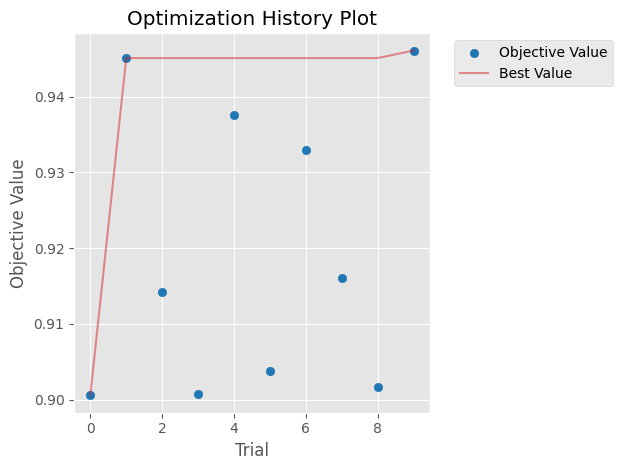

In [5]:
import optuna.visualization.matplotlib as optuna_mpl
import matplotlib.pyplot as plt

optuna_mpl.plot_optimization_history(study)
plt.show()

The Optuna optimization converged on the 6th out of 20 attempts, confirming that the chosen search space was sufficiently targeted.

In [6]:
print("Meilleurs paramètres :", study.best_params)
print("Meilleure AUC        :", study.best_value)

Meilleurs paramètres : {'max_depth': 9, 'learning_rate': 0.06281104665673783, 'subsample': 0.669339133197266, 'colsample_bytree': 0.6431542166020361, 'min_child_weight': 4, 'reg_alpha': 0.001490492267892824, 'reg_lambda': 0.0018251135583301588}
Meilleure AUC        : 0.9461065969646888


In [7]:
best_params = study.best_params.copy()

best_params.update({
    'n_estimators':          1000,
    'scale_pos_weight':      len(y[y==0]) / len(y[y==1]),
    'tree_method':           'hist',
    'eval_metric':           'auc',
    'early_stopping_rounds': 50,
    'random_state':          42,
    'n_jobs':                -1,
})

print("Final parameters used :")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Final parameters used :
  max_depth: 9
  learning_rate: 0.06281104665673783
  subsample: 0.669339133197266
  colsample_bytree: 0.6431542166020361
  min_child_weight: 4
  reg_alpha: 0.001490492267892824
  reg_lambda: 0.0018251135583301588
  n_estimators: 1000
  scale_pos_weight: 27.579586700866283
  tree_method: hist
  eval_metric: auc
  early_stopping_rounds: 50
  random_state: 42
  n_jobs: -1


In [8]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof    = np.zeros(len(X))
scores = []

for fold, (idx_train, idx_val) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

    model = XGBClassifier(**best_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=100
    )

    oof[idx_val] = model.predict_proba(X_val)[:, 1]
    scores.append(roc_auc_score(y_val, oof[idx_val]))
    print(f"Fold {fold+1} AUC : {scores[-1]:.4f}")

print(f"\nAUC moyenne    : {np.mean(scores):.4f}")
print(f"AUC OOF totale : {roc_auc_score(y, oof):.4f}")

[0]	validation_0-auc:0.86242
[100]	validation_0-auc:0.94516
[200]	validation_0-auc:0.95722
[300]	validation_0-auc:0.96210
[400]	validation_0-auc:0.96470
[500]	validation_0-auc:0.96611
[600]	validation_0-auc:0.96701
[700]	validation_0-auc:0.96792
[800]	validation_0-auc:0.96898
[900]	validation_0-auc:0.96947
[999]	validation_0-auc:0.97016
Fold 1 AUC : 0.9702
[0]	validation_0-auc:0.86079
[100]	validation_0-auc:0.94457
[200]	validation_0-auc:0.95753
[300]	validation_0-auc:0.96258
[400]	validation_0-auc:0.96582
[500]	validation_0-auc:0.96727
[600]	validation_0-auc:0.96874
[700]	validation_0-auc:0.96981
[800]	validation_0-auc:0.97058
[900]	validation_0-auc:0.97109
[999]	validation_0-auc:0.97154
Fold 2 AUC : 0.9715
[0]	validation_0-auc:0.86150
[100]	validation_0-auc:0.94226
[200]	validation_0-auc:0.95532
[300]	validation_0-auc:0.96157
[400]	validation_0-auc:0.96419
[500]	validation_0-auc:0.96558
[600]	validation_0-auc:0.96709
[700]	validation_0-auc:0.96819
[800]	validation_0-auc:0.96901
[900]

In [9]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof    = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
scores = []

for fold, (idx_train, idx_val) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

    model = XGBClassifier(**best_params)

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

    oof[idx_val] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

    scores.append(roc_auc_score(y_val, oof[idx_val]))
    print(f"Fold {fold+1} AUC : {scores[-1]:.4f}")

print(f"MeanAUC: {np.mean(scores):.4f}")
print(f"AUC OOF totale : {roc_auc_score(y, oof):.4f}")

[0]	validation_0-auc:0.86242
[100]	validation_0-auc:0.94516
[200]	validation_0-auc:0.95722
[300]	validation_0-auc:0.96210
[400]	validation_0-auc:0.96470
[500]	validation_0-auc:0.96611
[600]	validation_0-auc:0.96701
[700]	validation_0-auc:0.96792
[800]	validation_0-auc:0.96898
[900]	validation_0-auc:0.96947
[999]	validation_0-auc:0.97016
Fold 1 AUC : 0.9702
[0]	validation_0-auc:0.86079
[100]	validation_0-auc:0.94457
[200]	validation_0-auc:0.95753
[300]	validation_0-auc:0.96258
[400]	validation_0-auc:0.96582
[500]	validation_0-auc:0.96727
[600]	validation_0-auc:0.96874
[700]	validation_0-auc:0.96981
[800]	validation_0-auc:0.97058
[900]	validation_0-auc:0.97109
[999]	validation_0-auc:0.97154
Fold 2 AUC : 0.9715
[0]	validation_0-auc:0.86150
[100]	validation_0-auc:0.94226
[200]	validation_0-auc:0.95532
[300]	validation_0-auc:0.96157
[400]	validation_0-auc:0.96419
[500]	validation_0-auc:0.96558
[600]	validation_0-auc:0.96709
[700]	validation_0-auc:0.96819
[800]	validation_0-auc:0.96901
[900]

In [10]:
submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': test_preds
})
submission.to_csv('submission.csv', index=False)

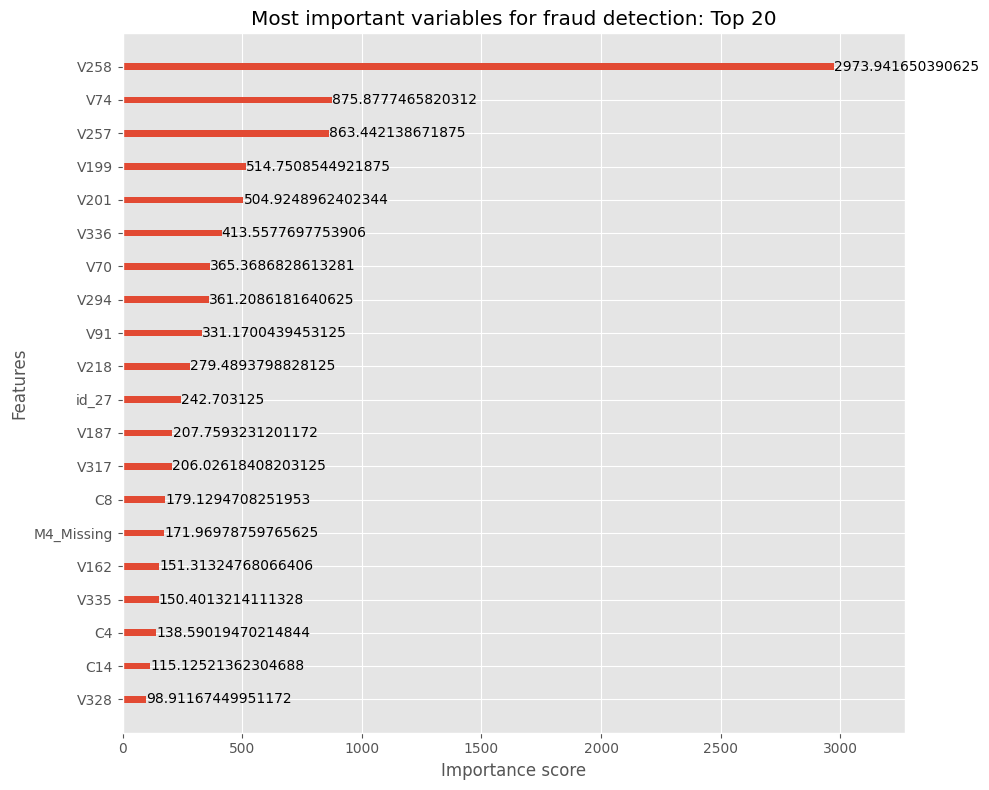

In [14]:
import xgboost


fig, ax = plt.subplots(figsize=(10, 8))
xgboost.plot_importance(model, max_num_features=20, ax=ax, importance_type='gain')
plt.title('Most important variables for fraud detection: Top 20')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()